<a href="https://colab.research.google.com/github/swathivenkatesan87/24ADI003-24BAD122-ML/blob/main/Exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME     : SWATHI
ROLL NO  : 24BAD122
EXPT NO  : 9
Dataset Loaded
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

User-Item Matrix Created

User Similarity Matrix Created

Top Similar Users for User 1:
userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64

Top Recommendations for User 1:
movieId
1200    4.801002
1610    4.298950
541  

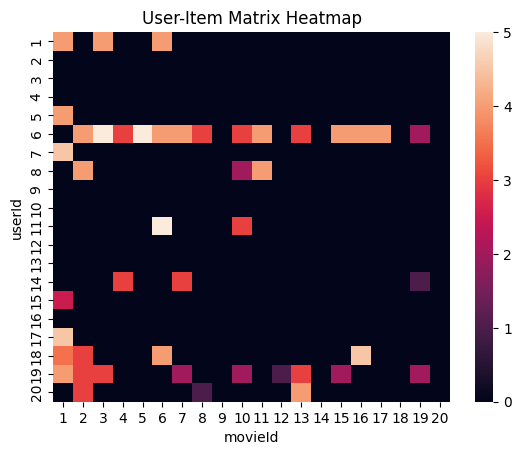

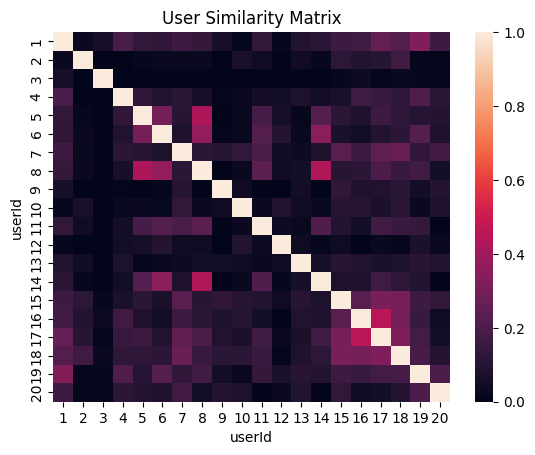

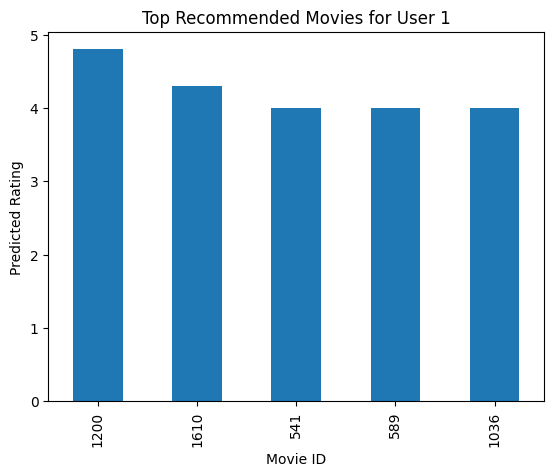

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
print("NAME     : SWATHI")
print("ROLL NO  : 24BAD122")
print("EXPT NO  : 9")
# 2. Load Dataset (ratings.csv)
data = pd.read_csv("ratings.csv")

print("Dataset Loaded")
print(data.head())

# ratings.csv columns usually:
# userId, movieId, rating, timestamp

# 3. Data Inspection
print("\nDataset Info:")
print(data.info())

# 4. Create User-Item Matrix
user_item_matrix = data.pivot_table(index='userId',
                                    columns='movieId',
                                    values='rating')

print("\nUser-Item Matrix Created")

# 5. Handle Missing Values
user_item_matrix_filled = user_item_matrix.fillna(0)

# 6. Compute Cosine Similarity
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

print("\nUser Similarity Matrix Created")

# 7. Get Similar Users
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    return similar_users.iloc[1:n+1]

# Test
print("\nTop Similar Users for User 1:")
print(get_similar_users(1))

# 8. Predict Ratings
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id)

    sim_user_ids = similar_users.index
    sim_scores = similar_users.values

    weighted_sum = np.dot(sim_scores,
                          user_item_matrix_filled.loc[sim_user_ids])

    sum_weights = np.sum(sim_scores)

    predicted = weighted_sum / sum_weights

    return pd.Series(predicted, index=user_item_matrix.columns)

# 9. Recommend Movies
def recommend_movies(user_id, n=5):
    predicted_ratings = predict_ratings(user_id)

    # Movies already watched
    watched = user_item_matrix.loc[user_id].dropna().index

    # Remove watched movies
    recommendations = predicted_ratings.drop(watched)

    return recommendations.sort_values(ascending=False).head(n)

# Test Recommendation
print("\nTop Recommendations for User 1:")
print(recommend_movies(1))

# 10. Evaluation (RMSE & MAE)
actual = []
predicted = []

for user in user_item_matrix.index[:50]:  # first 50 users
    pred = predict_ratings(user)
    actual_ratings = user_item_matrix.loc[user].dropna()

    for movie in actual_ratings.index:
        actual.append(actual_ratings[movie])
        predicted.append(pred[movie])

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nEvaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

# 11. Visualization

# Heatmap (small portion only)
plt.figure()
sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

# Similarity Heatmap
plt.figure()
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Matrix")
plt.show()

# Top Recommendations Chart
top_movies = recommend_movies(1)

plt.figure()
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()

NAME     : SWATHI
ROLL NO  : 24BAD122
EXPT NO  : 9
Dataset Loaded

Item-User Matrix Created

Item Similarity Computed

Top Similar Items:

movieId
1270    0.469494
364     0.462791
318     0.459610
1210    0.458225
356     0.456527
Name: 1, dtype: float64

Top Recommendations for User:

[(27706, np.float64(65.79292099371612)), (26958, np.float64(64.032288164117)), (65193, np.float64(64.032288164117)), (78703, np.float64(64.032288164117)), (80834, np.float64(64.032288164117)), (82088, np.float64(64.032288164117)), (84847, np.float64(64.032288164117)), (89678, np.float64(64.032288164117)), (90809, np.float64(64.032288164117)), (91337, np.float64(64.032288164117))]

Evaluation:
RMSE: 3.255


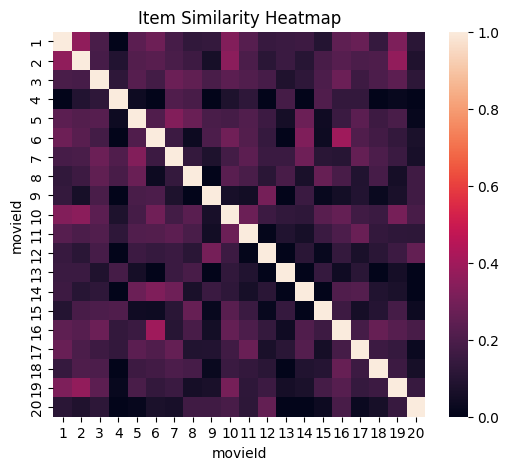

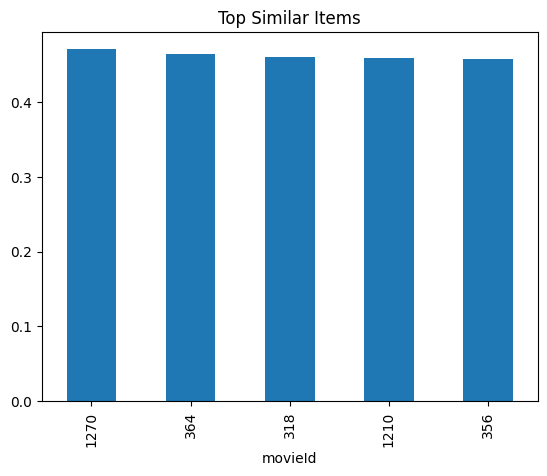

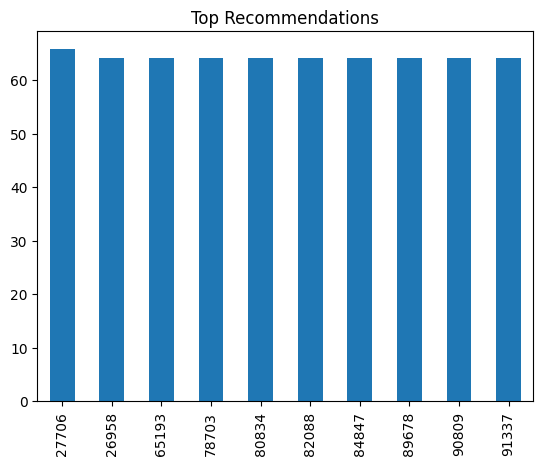

In [ ]:
# EXPT NO: 9
# ITEM-BASED COLLABORATIVE FILTERING
# NAME     : SWATHI
# ROLL NO  : 24BAD122

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# PRINT DETAILS
print("NAME     : SWATHI")
print("ROLL NO  : 24BAD122")
print("EXPT NO  : 9")

# LOAD DATASET
ratings = pd.read_csv("ratings.csv")

try:
    movies = pd.read_csv("movies.csv")
except:
    movies = None

print("Dataset Loaded\n")

# TRAIN TEST SPLIT
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# CREATE ITEM-USER MATRIX
item_user = train.pivot(index='movieId',
                        columns='userId',
                        values='rating').fillna(0)

print("Item-User Matrix Created\n")

# COMPUTE ITEM SIMILARITY
item_similarity = cosine_similarity(item_user)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user.index,
                                 columns=item_user.index)

print("Item Similarity Computed\n")

# FIND SIMILAR ITEMS
def get_similar_items(movie_id, n=5):
    similar = item_similarity_df[movie_id].sort_values(ascending=False)
    return similar[1:n+1]

movie_id = item_user.index[0]

print("Top Similar Items:\n")
print(get_similar_items(movie_id))

# RECOMMEND ITEMS
def recommend_items(user_id, n=10):
    user_ratings = train[train['userId'] == user_id]

    scores = {}

    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']

        similar_movies = item_similarity_df[movie]

        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in scores:
                scores[sim_movie] = 0
            scores[sim_movie] += sim_score * (rating / 5.0)  # normalized

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores[:n]

user_id = train['userId'].iloc[0]

recommendations = recommend_items(user_id)

# Show movie names if available
print("\nTop Recommendations for User:\n")

if movies is not None:
    rec_df = pd.DataFrame(recommendations, columns=['movieId', 'score'])
    rec_df = rec_df.merge(movies, on='movieId')
    print(rec_df[['movieId', 'title', 'score']])
else:
    print(recommendations)

# EVALUATION (FIXED)

# Create test matrix
test_matrix = test.pivot(index='movieId',
                        columns='userId',
                        values='rating').fillna(0)

# Common rows & columns
common_movies = item_user.index.intersection(test_matrix.index)
common_users = item_user.columns.intersection(test_matrix.columns)

train_common = item_user.loc[common_movies, common_users]
test_common = test_matrix.loc[common_movies, common_users]

# Recompute similarity
item_similarity_common = cosine_similarity(train_common)

# Prediction
pred = item_similarity_common.dot(train_common.values) / \
       np.abs(item_similarity_common).sum(axis=1).reshape(-1,1)

# Mask
mask = test_common.values > 0

rmse = np.sqrt(mean_squared_error(test_common.values[mask], pred[mask]))

print("\nEvaluation:")
print("RMSE:", round(rmse, 3))

# VISUALIZATION

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()

# Top Similar Items Graph
top_sim = get_similar_items(movie_id)
top_sim.plot(kind='bar')
plt.title("Top Similar Items")
plt.show()

# Recommendation Graph
if movies is not None:
    rec_df.set_index('title')['score'].plot(kind='bar')
else:
    pd.Series(dict(recommendations)).plot(kind='bar')

plt.title("Top Recommendations")
plt.show()

# END